In [1]:
import pandas as pd 
import numpy as np
df = pd.read_csv("/kaggle/input/datasets/ridwanul02/fake-news-training/fake_and_real_news.csv")
df.shape

(9900, 2)

In [2]:
df = df.drop_duplicates()
print("Duplicate Rows:", df.duplicated().sum())
df.shape

Duplicate Rows: 0


(9865, 2)

In [3]:
X = df["Text"]
y = df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training: {len(X_train)} | Test: {len(X_test)}")

Training: 7892 | Test: 1973


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


coutvector = Pipeline([("vectorizer", CountVectorizer()),("classifier", MultinomialNB())])
tfidvector = Pipeline([("vectorizer", TfidfVectorizer()),("classifier", MultinomialNB())])
logistic = Pipeline([("vectorizer", TfidfVectorizer()),("classifier", LogisticRegression())])


coutvector.fit(X_train, y_train)
tfidvector.fit(X_train, y_train)
logistic.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier', LogisticRegression())])

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'CountVectorizer + MultinomialNB': coutvector,
    'TfidfVectorizer + MultinomialNB': tfidvector,
    'TfidfVectorizer + LogisticRegression': logistic
}

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring
    )
    
    results.append({
        'Model': name,
        'Mean CV Accuracy': scores['test_accuracy'].mean(),
        'Std CV Accuracy': scores['test_accuracy'].std(),
        'Mean CV Macro F1': scores['test_f1_macro'].mean(),
        'Std CV Macro F1': scores['test_f1_macro'].std()
    })

    print(name)
    print(f"Mean Accuracy: {scores['test_accuracy'].mean():.4f}")
    print(f"Std Accuracy: {scores['test_accuracy'].std():.4f}")
    print(f"Mean Macro F1: {scores['test_f1_macro'].mean():.4f}")
    print(f"Std Macro F1: {scores['test_f1_macro'].std():.4f}")

CountVectorizer + MultinomialNB
Mean Accuracy: 0.9747
Std Accuracy: 0.0037
Mean Macro F1: 0.9747
Std Macro F1: 0.0037
TfidfVectorizer + MultinomialNB
Mean Accuracy: 0.9655
Std Accuracy: 0.0037
Mean Macro F1: 0.9655
Std Macro F1: 0.0037
TfidfVectorizer + LogisticRegression
Mean Accuracy: 0.9876
Std Accuracy: 0.0023
Mean Macro F1: 0.9876
Std Macro F1: 0.0023


In [6]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Mean CV Accuracy,Std CV Accuracy,Mean CV Macro F1,Std CV Macro F1
0,TfidfVectorizer + LogisticRegression,0.987583,0.002252,0.987580,0.002252
1,CountVectorizer + MultinomialNB,0.974658,0.003735,0.974655,0.003735
2,TfidfVectorizer + MultinomialNB,0.965535,0.003658,0.965521,0.003658


TfidfVectorizer + LogisticRegression is unambiguously the best-performing model across every metric shown in your table. As the mean cv is 0.98 other have 0.97 and 0.96, than in case of mean cv macro f1 0.987 where the other is 0.974 and 0.965, also std is lower in all case too thus this is the best model 


Accuracy: 0.9914
Confusion Matrix:
[[990  10]
 [  7 966]]
Classification Report:
              precision    recall  f1-score   support

        Fake     0.9930    0.9900    0.9915      1000
        Real     0.9898    0.9928    0.9913       973

    accuracy                         0.9914      1973
   macro avg     0.9914    0.9914    0.9914      1973
weighted avg     0.9914    0.9914    0.9914      1973



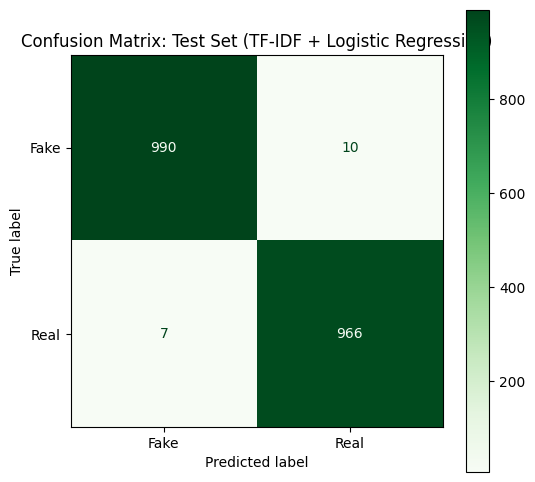

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

final_pipeline = Pipeline([("vectorizer", TfidfVectorizer()),("classifier", LogisticRegression())])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=['Fake', 'Real']))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    labels=['Fake', 'Real'],
    cmap='Greens',
    ax=ax
)
plt.title('Confusion Matrix: Test Set (TF-IDF + Logistic Regression)')
plt.show()

In [8]:
import pandas as pd

results = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'pred': y_pred
})

correct = results[results['actual'] == results['pred']]
incorrect = results[results['actual'] != results['pred']]

print("CORRECT PREDICTIONS:")
for x, row in correct.head(3).iterrows():
    print(row['actual'], "|", row['pred'])
    print(row['text'][:200])
    print()

print("MISCLASSIFIED:")
for y, row in incorrect.head(3).iterrows():
    print(row['actual'], "|", row['pred'])
    print(row['text'][:200])
    print()

CORRECT PREDICTIONS:
Real | Real
Thousands at rallies demand Trump release tax returns NEW YORK/WASHINGTON (Reuters) - Tens of thousands of people marched through midtown Manhattan and dozens of U.S. cities on Saturday to demand that

Real | Real
U.S. farmers slam Trump's Cuba clampdown, press forward with trade visit CHICAGO (Reuters) - U.S. farm groups criticized President Donald Trump’s decision to retreat from his predecessor’s opening tow

Fake | Fake
 FACEPALM: Gary Johnson Has ‘Aleppo Moment’ – Can’t Name A Single World Leader He Respects (VIDEO) Poor Gary Johnson. Poor, poor Gary Johnson. One thing is for sure, this man is not destined to be pre

MISCLASSIFIED:
Real | Fake
Clinton, in book, says Trump's debate stalking made her skin crawl WASHINGTON (Reuters) - Former Democratic presidential candidate Hillary Clinton says in her new book that Donald Trump made her skin 

Real | Fake
Trump gives Boy Scouts at jamboree a taste of Washington politics GLEN JEAN, West Virginia (Reut

The model is having hard time detecting in depth understandgin of the real news and if there is dramatic word predicting as real otherwise the model is perfroming quite well. spcially if there is source mentione the real stoires are gettng perfectly picked as the real news and but unable to predict clone fake news as fake for dramatic words.

In [9]:
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(final_pipeline, 'models/best_model.pkl')
print("Pipeline successfully saved to 'models/best_model.pkl'")

Pipeline successfully saved to 'models/best_model.pkl'


In [10]:
# import gradio as gr
# import joblib

# model = joblib.load('models/best_model.pkl')

# def predict_news(text):
#     if not text.strip():
#         return "Please enter valid text."
    
#     prediction = model.predict([text])[0]
#     probabilities = model.predict_proba([text])[0]
    
#     classes = model.classes_
#     prob_dict = {classes[i]: float(probabilities[i]) for i in range(len(classes))}
    
#     return prediction, prob_dict

# demo = gr.Interface(
#     fn=predict_news,
#     inputs=gr.Textbox(lines=5, placeholder="Paste news article content here..."),
#     outputs=[
#         gr.Label(label="Prediction"),
#         gr.JSON(label="Confidence Scores")
#     ],
#     title="Fake News Detector",
#     description="Enter news article text below to classify it as Real or Fake."
# )

# demo.launch(inline=True, share=False)